In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

Using TensorFlow backend.
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/t

In [2]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [3]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [4]:



data = awgn(data, snr_range)

In [ ]:
print(data)

In [5]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)
augmented_sample = apply_random_noise(augmented_sample, noise_level)


In [6]:
data.shape

(5000, 8192)

/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


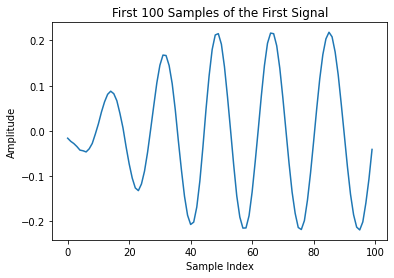

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = data  # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


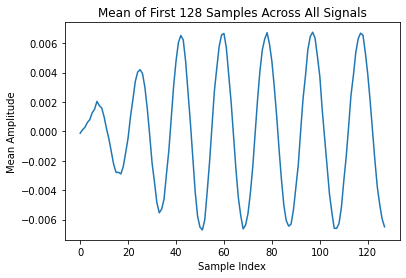

Suspected Preamble: [-1.25801255e-04+9.07073640e-04j  1.15605113e-04+8.76257499e-04j
  2.77739691e-04+1.06756846e-03j  6.03115063e-04+1.36269683e-03j
  7.95227696e-04+1.11025503e-03j  1.25660611e-03+6.98255549e-04j
  1.50175397e-03+3.86545892e-04j  2.03934030e-03+3.45895547e-06j
  1.75501654e-03-7.99200342e-04j  1.58563806e-03-1.23416988e-03j
  9.81647470e-04-1.81205131e-03j  1.78948649e-04-2.01575733e-03j
 -5.14329389e-04-2.26027512e-03j -1.39491636e-03-2.38818895e-03j
 -2.26086521e-03-1.81986571e-03j -2.79365625e-03-8.46242146e-04j
 -2.78748176e-03+1.13139677e-04j -2.89058614e-03+1.18991625e-03j
 -2.37605083e-03+2.11938037e-03j -1.43801315e-03+2.79541228e-03j
 -4.44338800e-04+3.29809584e-03j  9.97801255e-04+3.34953648e-03j
  2.16266408e-03+3.06661166e-03j  3.39290484e-03+2.15972529e-03j
  4.03325030e-03+8.18190257e-04j  4.19326170e-03-5.20379724e-04j
  3.93697389e-03-2.40660834e-03j  3.00594193e-03-3.49036820e-03j
  1.55213844e-03-4.70686555e-03j -2.35905476e-04-4.92181560e-03j
 -2.1

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is a NumPy array with shape (30000, 8192)

# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 128  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 128 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


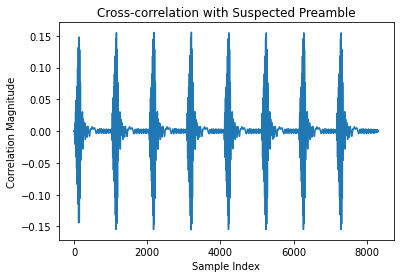

Peak correlation index: 3201
Peak correlation value: (-0.027683882683221025+0.15518676620151167j)
Synchronized signal start index: 3074


In [10]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [12]:
import numpy as np

# Given values
peak_index =3201
preamble_length = 128  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [-0.17983999+0.12532331j -0.17239213+0.13287634j -0.15804376+0.15081515j
 -0.13643758+0.17134925j -0.1023096 +0.19390613j -0.06066811+0.21110068j
 -0.00837683+0.21928359j  0.04781775+0.21369341j  0.10395027+0.19369924j
  0.15448232+0.15395834j  0.19398565+0.09891705j  0.21486688+0.03533051j
  0.21806336-0.036369j    0.19357999-0.10449393j  0.14889222-0.16306922j
  0.08704019-0.20236346j  0.01304698-0.22062132j -0.06385173-0.21107018j
 -0.13234623-0.17485275j -0.18368433-0.11943577j -0.21377545-0.04585032j
 -0.21525186+0.03235187j -0.19137193+0.10704119j -0.14064974+0.17015801j
 -0.07249232+0.20716962j  0.00401669+0.21961569j  0.08553983+0.20352067j
  0.15244783+0.15899931j  0.19926291+0.09318118j  0.21886279+0.01433929j
  0.21042586-0.06264004j  0.17367044-0.13396066j  0.11183967-0.18805125j
  0.04124755-0.21645721j -0.03911315-0.21672765j -0.11201908-0.18695626j
 -0.17381358-0.1342611j  -0.20898784-0.06461158j -0.21848109+0.01126238j
 -0.20136752+0.09128873j -0.154

In [13]:
preamble=suspected_preamble
data_input=data

In [15]:
preamble

array([-0.17983999+0.12532331j, -0.17239213+0.13287634j,
       -0.15804376+0.15081515j, -0.13643758+0.17134925j,
       -0.1023096 +0.19390613j, -0.06066811+0.21110068j,
       -0.00837683+0.21928359j,  0.04781775+0.21369341j,
        0.10395027+0.19369924j,  0.15448232+0.15395834j,
        0.19398565+0.09891705j,  0.21486688+0.03533051j,
        0.21806336-0.036369j  ,  0.19357999-0.10449393j,
        0.14889222-0.16306922j,  0.08704019-0.20236346j,
        0.01304698-0.22062132j, -0.06385173-0.21107018j,
       -0.13234623-0.17485275j, -0.18368433-0.11943577j,
       -0.21377545-0.04585032j, -0.21525186+0.03235187j,
       -0.19137193+0.10704119j, -0.14064974+0.17015801j,
       -0.07249232+0.20716962j,  0.00401669+0.21961569j,
        0.08553983+0.20352067j,  0.15244783+0.15899931j,
        0.19926291+0.09318118j,  0.21886279+0.01433929j,
        0.21042586-0.06264004j,  0.17367044-0.13396066j,
        0.11183967-0.18805125j,  0.04124755-0.21645721j,
       -0.03911315-0.21672765j,

In [16]:
import numpy as np

def generate_pilot_sequence(preamble_array):
    # Extract the real and imaginary parts of the preamble array
    real_part = np.real(preamble_array)
    imag_part = np.imag(preamble_array)
    
    # Combine the real and imaginary parts to form the pilot sequence
    pilot_sequence = np.column_stack((real_part, imag_part)).flatten()
    
    return pilot_sequence

# Example usage
preamble = np.array([-0.17983999+0.12532331j, -0.17239213+0.13287634j,
       -0.15804376+0.15081515j, -0.13643758+0.17134925j,
       -0.1023096 +0.19390613j, -0.06066811+0.21110068j,
       -0.00837683+0.21928359j,  0.04781775+0.21369341j,
        0.10395027+0.19369924j,  0.15448232+0.15395834j,
        0.19398565+0.09891705j,  0.21486688+0.03533051j,
        0.21806336-0.036369j  ,  0.19357999-0.10449393j,
        0.14889222-0.16306922j,  0.08704019-0.20236346j,
        0.01304698-0.22062132j, -0.06385173-0.21107018j,
       -0.13234623-0.17485275j, -0.18368433-0.11943577j,
       -0.21377545-0.04585032j, -0.21525186+0.03235187j,
       -0.19137193+0.10704119j, -0.14064974+0.17015801j,
       -0.07249232+0.20716962j,  0.00401669+0.21961569j,
        0.08553983+0.20352067j,  0.15244783+0.15899931j,
        0.19926291+0.09318118j,  0.21886279+0.01433929j,
        0.21042586-0.06264004j,  0.17367044-0.13396066j,
        0.11183967-0.18805125j,  0.04124755-0.21645721j,
       -0.03911315-0.21672765j, -0.11201908-0.18695626j,
       -0.17381358-0.1342611j , -0.20898784-0.06461158j,
       -0.21848109+0.01126238j, -0.20136752+0.09128873j,
       -0.1547835 +0.15534129j, -0.0905585 +0.20032302j,
       -0.01199397+0.21926462j,  0.06454413+0.20784871j,
        0.13098965+0.17431195j,  0.18584651+0.11678774j,
        0.21662675+0.04248091j,  0.21714142-0.03453081j,
        0.19310735-0.10773924j,  0.14008988-0.16810664j,
        0.07346001-0.20713646j, -0.0046857 -0.22018713j,
       -0.08195376-0.20492354j, -0.1457515 -0.16240174j,
       -0.19220779-0.10437257j, -0.21643008-0.03415955j,
       -0.21544272+0.04260996j, -0.18595821+0.11375382j,
       -0.13715267+0.1724733j , -0.06941241+0.20790828j,
        0.00466363+0.21978963j,  0.08152633+0.20289584j,
        0.14571282+0.16393631j,  0.1948171 +0.10210199j,
        0.21705167+0.03171283j,  0.21646087-0.04235359j,
        0.18939086-0.11129088j,  0.14025201-0.1677389j ,
        0.07728728-0.20423502j,  0.00476509-0.22103655j,
       -0.07110388-0.20970411j, -0.13702756-0.17304913j,
       -0.18588427-0.11722019j, -0.21599002-0.04566256j,
       -0.21728122+0.02494619j, -0.19551984+0.09589774j,
       -0.15228832+0.15510544j, -0.09444237+0.19748668j,
       -0.02481006+0.2163709j ,  0.04710534+0.2140527j ,
        0.11714948+0.18636576j,  0.17072121+0.13883476j,
        0.20649032+0.0739206j ,  0.21963112+0.00270893j,
        0.21055373-0.06805754j,  0.17427807-0.13091947j,
        0.12102735-0.18152295j,  0.05891953-0.21134972j,
       -0.01164854-0.21854084j, -0.08000656-0.20360382j,
       -0.14057577-0.16850408j, -0.18725507-0.11498624j,
       -0.21549529-0.04991411j, -0.21969879+0.0235159j ,
       -0.20018256+0.09041347j, -0.16014614+0.15019426j,
       -0.10541932+0.19249198j, -0.03988718+0.2158042j ,
        0.02981589+0.21632439j,  0.09746094+0.19691719j,
        0.15446577+0.1567665j ,  0.19433926+0.10271182j,
        0.2166485 +0.03395938j,  0.21818985-0.03606644j,
        0.19620782-0.0997649j ,  0.15569434-0.15390311j,
        0.10137212-0.19269811j,  0.03681666-0.21533666j,
       -0.03186885-0.21670154j, -0.09786463-0.19683579j,
       -0.15218901-0.1579647j , -0.19335672-0.10306981j,
       -0.21617754-0.03868014j, -0.21774616+0.02609838j,
       -0.19815195+0.09213167j, -0.16241728+0.14511073j,
       -0.11316243+0.1885315j , -0.05200569+0.21229647j,
        0.01623083+0.21816755j,  0.08356937+0.20243258j,
        0.13827561+0.17031978j,  0.18170382+0.12224218j,
        0.2106942 +0.05927796j,  0.21905257-0.00418836j,
        0.20854279-0.06629515j,  0.17790948-0.1263807j ,
        0.13342317-0.17396031j,  0.07923457-0.20405715j])  # Replace with your actual preamble array
pilot_sequence = generate_pilot_sequence(preamble)
print(pilot_sequence)


[-0.17983999  0.12532331 -0.17239213  0.13287634 -0.15804376  0.15081515
 -0.13643758  0.17134925 -0.1023096   0.19390613 -0.06066811  0.21110068
 -0.00837683  0.21928359  0.04781775  0.21369341  0.10395027  0.19369924
  0.15448232  0.15395834  0.19398565  0.09891705  0.21486688  0.03533051
  0.21806336 -0.036369    0.19357999 -0.10449393  0.14889222 -0.16306922
  0.08704019 -0.20236346  0.01304698 -0.22062132 -0.06385173 -0.21107018
 -0.13234623 -0.17485275 -0.18368433 -0.11943577 -0.21377545 -0.04585032
 -0.21525186  0.03235187 -0.19137193  0.10704119 -0.14064974  0.17015801
 -0.07249232  0.20716962  0.00401669  0.21961569  0.08553983  0.20352067
  0.15244783  0.15899931  0.19926291  0.09318118  0.21886279  0.01433929
  0.21042586 -0.06264004  0.17367044 -0.13396066  0.11183967 -0.18805125
  0.04124755 -0.21645721 -0.03911315 -0.21672765 -0.11201908 -0.18695626
 -0.17381358 -0.1342611  -0.20898784 -0.06461158 -0.21848109  0.01126238
 -0.20136752  0.09128873 -0.1547835   0.15534129 -0

In [17]:
pilot_sequence

array([-0.17983999,  0.12532331, -0.17239213,  0.13287634, -0.15804376,
        0.15081515, -0.13643758,  0.17134925, -0.1023096 ,  0.19390613,
       -0.06066811,  0.21110068, -0.00837683,  0.21928359,  0.04781775,
        0.21369341,  0.10395027,  0.19369924,  0.15448232,  0.15395834,
        0.19398565,  0.09891705,  0.21486688,  0.03533051,  0.21806336,
       -0.036369  ,  0.19357999, -0.10449393,  0.14889222, -0.16306922,
        0.08704019, -0.20236346,  0.01304698, -0.22062132, -0.06385173,
       -0.21107018, -0.13234623, -0.17485275, -0.18368433, -0.11943577,
       -0.21377545, -0.04585032, -0.21525186,  0.03235187, -0.19137193,
        0.10704119, -0.14064974,  0.17015801, -0.07249232,  0.20716962,
        0.00401669,  0.21961569,  0.08553983,  0.20352067,  0.15244783,
        0.15899931,  0.19926291,  0.09318118,  0.21886279,  0.01433929,
        0.21042586, -0.06264004,  0.17367044, -0.13396066,  0.11183967,
       -0.18805125,  0.04124755, -0.21645721, -0.03911315, -0.21

In [18]:
import numpy as np




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...


Most Common Synchronization Offset: 7177


/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py:26: ComplexWarning: Casting complex values to real discards the imaginary part


In [136]:
import numpy as np


suspected_preamble = np.array([-0.06458863+0.21065429j, -0.00826191+0.21357569j,
        0.04395745+0.22043189j,  0.10750568+0.18633216j,
        0.15226798+0.14927498j,  0.19364056+0.10013671j,
        0.21668914+0.04101746j,  0.21485904-0.0397009j ,
        0.19377607-0.10362717j,  0.14706706-0.1569459j ,
        0.08792618-0.20881249j,  0.01397906-0.22145089j,
       -0.06344193-0.20682935j, -0.1327184 -0.17117766j,
       -0.17717411-0.11665229j, -0.21074315-0.0469986j ,
       -0.21671624+0.03399485j, -0.19489115+0.10340677j,
       -0.13833273+0.16529434j, -0.06667861+0.20524162j,
       -0.001785  +0.21755046j,  0.0894127 +0.19673925j,
        0.15570057+0.16146279j,  0.19554746+0.09289848j,
        0.22327226+0.01519953j,  0.20384738-0.06153289j,
        0.17151897-0.13023065j,  0.10908023-0.1864561j ,
        0.04409277-0.21605995j, -0.04542725-0.21697768j,
       -0.11477473-0.18687998j, -0.17086451-0.13883091j,
       -0.20752095-0.06317033j, -0.22662411+0.01044015j,
       -0.20074351+0.08852309j, -0.15085028+0.1557506j ,
       -0.08958471+0.19604756j, -0.01566466+0.21282341j,
        0.07064355+0.20922216j,  0.13705403+0.18034828j,
        0.1823614 +0.11943036j,  0.21787232+0.03876985j,
        0.22200638-0.03611122j,  0.19486456-0.10825363j,
        0.13803366-0.1720362j ,  0.06738918-0.21033527j,
       -0.00215065-0.22488955j, -0.07548984-0.20661537j,
       -0.14727122-0.16238988j, -0.19679002-0.10738435j])

known_pilot_sequence =np.array([-0.06458863+0.21065429j, -0.00826191+0.21357569j, 0.04395745+0.22043189j, 0.10750568+0.18633216j, 0.15226798+0.14927498j, 0.19364056+0.10013671j, 0.21668914+0.04101746j, 0.21485904-0.0397009j, 0.19377607-0.10362717j, 0.14706706-0.1569459j, 0.08792618-0.20881249j, 0.01397906-0.22145089j, -0.06344193-0.20682935j, -0.1327184-0.17117766j, -0.17717411-0.11665229j, -0.21074315-0.0469986j, -0.21671624+0.03399485j, -0.19489115+0.10340677j, -0.13833273+0.16529434j, -0.06667861+0.20524162j, -0.001785+0.21755046j, 0.0894127+0.19673925j, 0.15570057+0.16146279j, 0.19554746+0.09289848j, 0.22327226+0.01519953j, 0.20384738-0.06153289j, 0.17151897-0.13023065j, 0.10908023-0.1864561j, 0.04409277-0.21605995j, -0.04542725-0.21697768j, -0.11477473-0.18687998j, -0.17086451-0.13883091j, -0.20752095-0.06317033j, -0.22662411+0.01044015j, -0.20074351+0.08852309j, -0.15085028+0.1557506j, -0.08958471+0.19604756j, -0.01566466+0.21282341j, 0.07064355+0.20922216j, 0.13705403+0.18034828j, 0.1823614+0.11943036j, 0.21787232+0.03876985j, 0.22200638-0.03611122j, 0.19486456-0.10825363j, 0.13803366-0.1720362j, 0.06738918-0.21033527j, -0.00215065-0.22488955j, -0.07548984-0.20661537j, -0.14727122-0.16238988j, -0.19679002-0.10738435j])




# Find the index of the best match between the suspected preamble and the known pilot sequence
best_match_index = np.argmax(np.correlate(suspected_preamble, known_pilot_sequence, mode='full'))

# Extract the pilot sequence from the suspected preamble based on the best match index
pilot_sequence = suspected_preamble[best_match_index:best_match_index+len(known_pilot_sequence)]

print("Pilot sequence:", pilot_sequence)


Pilot sequence: [-0.19679002-0.10738435j]


In [19]:
pilot_sequence

array([-0.17983999,  0.12532331, -0.17239213,  0.13287634, -0.15804376,
        0.15081515, -0.13643758,  0.17134925, -0.1023096 ,  0.19390613,
       -0.06066811,  0.21110068, -0.00837683,  0.21928359,  0.04781775,
        0.21369341,  0.10395027,  0.19369924,  0.15448232,  0.15395834,
        0.19398565,  0.09891705,  0.21486688,  0.03533051,  0.21806336,
       -0.036369  ,  0.19357999, -0.10449393,  0.14889222, -0.16306922,
        0.08704019, -0.20236346,  0.01304698, -0.22062132, -0.06385173,
       -0.21107018, -0.13234623, -0.17485275, -0.18368433, -0.11943577,
       -0.21377545, -0.04585032, -0.21525186,  0.03235187, -0.19137193,
        0.10704119, -0.14064974,  0.17015801, -0.07249232,  0.20716962,
        0.00401669,  0.21961569,  0.08553983,  0.20352067,  0.15244783,
        0.15899931,  0.19926291,  0.09318118,  0.21886279,  0.01433929,
        0.21042586, -0.06264004,  0.17367044, -0.13396066,  0.11183967,
       -0.18805125,  0.04124755, -0.21645721, -0.03911315, -0.21

In [20]:
import numpy as np

# Define the pilot sequence (replace this with your actual pilot sequence)
#pilot = np.random.randn(len(preamble))
pilot=np.array([-0.17983999,  0.12532331, -0.17239213,  0.13287634, -0.15804376,
        0.15081515, -0.13643758,  0.17134925, -0.1023096 ,  0.19390613,
       -0.06066811,  0.21110068, -0.00837683,  0.21928359,  0.04781775,
        0.21369341,  0.10395027,  0.19369924,  0.15448232,  0.15395834,
        0.19398565,  0.09891705,  0.21486688,  0.03533051,  0.21806336,
       -0.036369  ,  0.19357999, -0.10449393,  0.14889222, -0.16306922,
        0.08704019, -0.20236346,  0.01304698, -0.22062132, -0.06385173,
       -0.21107018, -0.13234623, -0.17485275, -0.18368433, -0.11943577,
       -0.21377545, -0.04585032, -0.21525186,  0.03235187, -0.19137193,
        0.10704119, -0.14064974,  0.17015801, -0.07249232,  0.20716962,
        0.00401669,  0.21961569,  0.08553983,  0.20352067,  0.15244783,
        0.15899931,  0.19926291,  0.09318118,  0.21886279,  0.01433929,
        0.21042586, -0.06264004,  0.17367044, -0.13396066,  0.11183967,
       -0.18805125,  0.04124755, -0.21645721, -0.03911315, -0.21672765,
       -0.11201908, -0.18695626, -0.17381358, -0.1342611 , -0.20898784,
       -0.06461158, -0.21848109,  0.01126238, -0.20136752,  0.09128873,
       -0.1547835 ,  0.15534129, -0.0905585 ,  0.20032302, -0.01199397,
        0.21926462,  0.06454413,  0.20784871,  0.13098965,  0.17431195,
        0.18584651,  0.11678774,  0.21662675,  0.04248091,  0.21714142,
       -0.03453081,  0.19310735, -0.10773924,  0.14008988, -0.16810664,
        0.07346001, -0.20713646, -0.0046857 , -0.22018713, -0.08195376,
       -0.20492354, -0.1457515 , -0.16240174, -0.19220779, -0.10437257,
       -0.21643008, -0.03415955, -0.21544272,  0.04260996, -0.18595821,
        0.11375382, -0.13715267,  0.1724733 , -0.06941241,  0.20790828,
        0.00466363,  0.21978963,  0.08152633,  0.20289584,  0.14571282,
        0.16393631,  0.1948171 ,  0.10210199,  0.21705167,  0.03171283,
        0.21646087, -0.04235359,  0.18939086, -0.11129088,  0.14025201,
       -0.1677389 ,  0.07728728, -0.20423502,  0.00476509, -0.22103655,
       -0.07110388, -0.20970411, -0.13702756, -0.17304913, -0.18588427,
       -0.11722019, -0.21599002, -0.04566256, -0.21728122,  0.02494619,
       -0.19551984,  0.09589774, -0.15228832,  0.15510544, -0.09444237,
        0.19748668, -0.02481006,  0.2163709 ,  0.04710534,  0.2140527 ,
        0.11714948,  0.18636576,  0.17072121,  0.13883476,  0.20649032,
        0.0739206 ,  0.21963112,  0.00270893,  0.21055373, -0.06805754,
        0.17427807, -0.13091947,  0.12102735, -0.18152295,  0.05891953,
       -0.21134972, -0.01164854, -0.21854084, -0.08000656, -0.20360382,
       -0.14057577, -0.16850408, -0.18725507, -0.11498624, -0.21549529,
       -0.04991411, -0.21969879,  0.0235159 , -0.20018256,  0.09041347,
       -0.16014614,  0.15019426, -0.10541932,  0.19249198, -0.03988718,
        0.2158042 ,  0.02981589,  0.21632439,  0.09746094,  0.19691719,
        0.15446577,  0.1567665 ,  0.19433926,  0.10271182,  0.2166485 ,
        0.03395938,  0.21818985, -0.03606644,  0.19620782, -0.0997649 ,
        0.15569434, -0.15390311,  0.10137212, -0.19269811,  0.03681666,
       -0.21533666, -0.03186885, -0.21670154, -0.09786463, -0.19683579,
       -0.15218901, -0.1579647 , -0.19335672, -0.10306981, -0.21617754,
       -0.03868014, -0.21774616,  0.02609838, -0.19815195,  0.09213167,
       -0.16241728,  0.14511073, -0.11316243,  0.1885315 , -0.05200569,
        0.21229647,  0.01623083,  0.21816755,  0.08356937,  0.20243258,
        0.13827561,  0.17031978,  0.18170382,  0.12224218,  0.2106942 ,
        0.05927796,  0.21905257, -0.00418836,  0.20854279, -0.06629515,
        0.17790948, -0.1263807 ,  0.13342317, -0.17396031,  0.07923457,
       -0.20405715]
)




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    
    # Carrier Frequency Offset (CFO) Compensation
    from scipy.fft import fft, ifft

    def estimate_cfo(signal, pilot):
        pilot_length = len(pilot)
        signal_pilot = signal[:pilot_length]
        phase_diff = np.angle(np.sum(signal_pilot * np.conj(pilot)))
        cfo = phase_diff / (2 * np.pi * pilot_length)
        return cfo

    def compensate_cfo(signal, cfo):
        n = np.arange(len(signal))
        return signal * np.exp(-1j * 2 * np.pi * cfo * n)

    # Example CFO compensation
    cfo_estimates = np.array([estimate_cfo(sig, pilot) for sig in synchronized_data])
    compensated_data = np.array([compensate_cfo(sig, cfo) for sig, cfo in zip(synchronized_data, cfo_estimates)])


/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py:82: ComplexWarning: Casting complex values to real discards the imaginary part


Most Common Synchronization Offset: 7177


In [21]:
compensated_data.shape

(5000, 1015)

In [22]:
compensated_data.shape

(5000, 1015)

In [24]:
data=compensated_data

In [145]:
data.shape

(5000, 1018)

In [26]:

        #''' Normalize the signal.'''
s_norm = np.zeros(data.shape, dtype=complex)
        
for i in range(data.shape[0]):
        
            sig_amplitude = np.abs(data[i])
            rms = np.sqrt(np.mean(sig_amplitude**2))
            s_norm[i] = data[i]/rms
        


In [27]:
s_norm.shape

(5000, 1015)

In [29]:
data=s_norm

In [30]:
data.shape

(5000, 1015)

In [94]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming 'data' is your complex-valued NumPy array with shape (5000, 1015)
data =data
# Separate the real and imaginary parts
data_real = np.real(data)
data_imag = np.imag(data)

# Concatenate the real and imaginary parts along the feature axis
data_combined = np.concatenate((data_real, data_imag), axis=1)

# Step 1: Standardize the data
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data_combined)

# Step 2: Apply PCA
n_components = 1000  # Adjust this number based on your needs
pca = PCA(n_components=n_components)

# Fit PCA on the standardized data
principal_components = pca.fit_transform(data_standardized)

# Step 3: Check the explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(f"Explained variance by each component: {explained_variance}")
print(f"Cumulative explained variance: {cumulative_variance}")

# Step 4: Use the transformed data
print(f"Shape of transformed data: {principal_components.shape}")

# principal_components now contains the data transformed into the principal component space


Explained variance by each component: [3.76200380e-01 3.22025021e-01 2.04857324e-01 9.01218939e-02
 2.02604475e-03 1.60147263e-03 1.14555366e-03 8.58578179e-04
 1.16845166e-05 7.94103247e-06 6.36949343e-06 6.19931741e-06
 6.10012448e-06 6.05827345e-06 5.91916283e-06 5.87290467e-06
 5.75559887e-06 5.68067390e-06 5.60959196e-06 5.52495602e-06
 5.37778140e-06 5.35644714e-06 5.31572471e-06 5.26526800e-06
 5.21189835e-06 5.14912535e-06 5.11357895e-06 5.02485650e-06
 5.01779932e-06 4.95579168e-06 4.85460152e-06 4.82370099e-06
 4.80069618e-06 4.77579398e-06 4.73814962e-06 4.70712796e-06
 4.66629461e-06 4.63341515e-06 4.57417026e-06 4.54700333e-06
 4.54000775e-06 4.46904071e-06 4.42681897e-06 4.37274541e-06
 4.35566861e-06 4.30843530e-06 4.29744169e-06 4.25429678e-06
 4.23380916e-06 4.20522288e-06 4.17331885e-06 4.14143813e-06
 4.09037010e-06 4.05743002e-06 4.02925377e-06 3.99420868e-06
 3.97028129e-06 3.94966745e-06 3.92139366e-06 3.87454638e-06
 3.84874520e-06 3.83245602e-06 3.80299894e-06 3

In [95]:
principal_components.shape

(5000, 1000)

In [32]:
import numpy as np
from scipy.signal import spectrogram

# Define parameters for spectrogram computation
win_len = 256  # Adjusted window length
overlap = 128  # Overlap length

# Assuming 'data' is a list or array of samples
spectrograms = []
for sample in data:
    # Compute spectrogram for the current sample
    _, _, spec = spectrogram(sample.squeeze(), window='boxcar', nperseg=win_len, noverlap=overlap)
    
    # Append the spectrogram to the list
    spectrograms.append(spec)

# Convert the list of spectrograms to a numpy array
spectrograms_array = np.array(spectrograms)

# Reshape the spectrograms array to (5000, num_row, num_column)
# Assuming num_row and num_column are the dimensions of your spectrograms
num_row = spectrograms_array.shape[1]
num_column = spectrograms_array.shape[2]
spectrograms_array = spectrograms_array.reshape(-1, num_row, num_column)

# Verify the shape of the spectrograms array
print("Shape of spectrograms array:", spectrograms_array.shape)


/opt/conda/envs/project/lib/python3.6/site-packages/scipy/signal/spectral.py:1812: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '


Shape of spectrograms array: (5000, 256, 6)


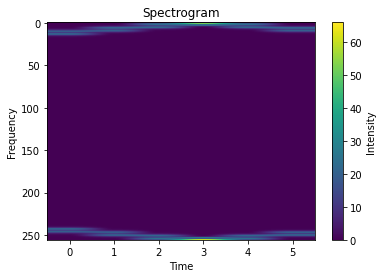

In [34]:
import matplotlib.pyplot as plt

# Select a sample index to visualize its spectrogram
sample_index = 4

# Visualize the spectrogram
plt.imshow(spectrograms_array[sample_index], aspect='auto', cmap='viridis')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(label='Intensity')
plt.show()


In [ ]:
print("Spectrogram:")
print(spectrograms_array[0])

In [36]:
spectrograms_array.shape

(5000, 256, 6)

In [160]:
data.shape

(5000, 1018)

In [96]:
principal_components.shape

(5000, 1000)

In [98]:
# Normalize the magnitude of the spectrograms
magnitude = np.abs(principal_components)
mean = np.nanmean(magnitude)
std = np.nanstd(magnitude)
magnitude_normalized = (magnitude - mean) / std

# Normalize phase
phase = np.angle(principal_components)
phase_normalized = (phase + np.pi) / (2 * np.pi)  # Scale phase to [0, 1]

# Combine magnitude and phase
data_normalized = np.stack((magnitude_normalized, phase_normalized), axis=-1)


In [ ]:
# Normalize the magnitude of the spectrograms
magnitude = np.abs(spectrograms_array)
mean = np.nanmean(magnitude)
std = np.nanstd(magnitude)
magnitude_normalized = (magnitude - mean) / std

# Normalize phase
phase = np.angle(spectrograms_array)
phase_normalized = (phase + np.pi) / (2 * np.pi)  # Scale phase to [0, 1]

# Combine magnitude and phase
data_normalized = np.stack((magnitude_normalized, phase_normalized), axis=-1)


In [99]:
data_normalized.shape

(5000, 1000, 2)

In [100]:
# Reshape the data for 2D CNN
# Ensure the reshaping dimensions match the size of data_normalized
# Since data_normalized is of shape (5000, 102, 2), the reshaped array should be of shape (5000, 256, 6, 2)
data_2d_cnn_input = data_normalized.reshape((data_normalized.shape[0], data_normalized.shape[1], 2))

# Now 'data_2d_cnn_input' can be used as input to your 2D CNN model

In [101]:
data_real_values=data_2d_cnn_input

In [102]:
data_real_values.shape
data_real_values.shape[1]

1000

In [103]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [105]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [106]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape= (data_real_values.shape[1], 2)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation='sigmoid'))

#cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
#cnn_model.summary()


In [109]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

model_to_train = cnn_model
#model_to_train = lstm_model
#model_to_train = CuDNNlstm_model\n",
#model_to_train = cnn_lstm_model
#model_to_train = mlp_model
#model_to_train = simpleRNN_model\n",
#model_to_train = gru_model\n",
#model_to_train=CNN_LSTM_model\n",
    
#loss1 = 'sparse_categorical_crossentropy'
#loss2 = 'binary_crossentropy'
#loss3 = keras.losses.BinaryFocalCrossentropy(),
    
#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/
    
#model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])
#train_history = model_to_train.fit(data_real_values_train, label_train, 
#                                       validation_data = (data_real_values_test, label_test),
#                                      epochs=50, batch_size=32)




callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
   # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#for model in models:
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                       validation_data = (data_real_values_test, label_test),
                                       epochs=700, batch_size=32,
                                       callbacks=callbacks,
                                       )

   


Train on 4000 samples, validate on 1000 samples
Epoch 1/700
4000/4000 [==============================] - 8s 2ms/step - loss: 2.3687 - acc: 0.0955 - val_loss: 3.3974 - val_acc: 0.1030
Epoch 2/700
4000/4000 [==============================] - 7s 2ms/step - loss: 2.3143 - acc: 0.1000 - val_loss: 3.5441 - val_acc: 0.0940
Epoch 3/700
4000/4000 [==============================] - 7s 2ms/step - loss: 2.3143 - acc: 0.0985 - val_loss: 2.7419 - val_acc: 0.1070
Epoch 4/700
4000/4000 [==============================] - 7s 2ms/step - loss: 2.3154 - acc: 0.0990 - val_loss: 2.3867 - val_acc: 0.1170
Epoch 5/700
4000/4000 [==============================] - 7s 2ms/step - loss: 2.3048 - acc: 0.1005 - val_loss: 2.3015 - val_acc: 0.1120
Epoch 6/700
4000/4000 [==============================] - 7s 2ms/step - loss: 2.3071 - acc: 0.0970 - val_loss: 2.3022 - val_acc: 0.1030
Epoch 7/700
4000/4000 [==============================] - 7s 2ms/step - loss: 2.3049 - acc: 0.0960 - val_loss: 2.3024 - val_acc: 0.1110
Epoch 8

KeyboardInterrupt: 

In [ ]:
model_to_train.save('cnn_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'cnn')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score
#confusion matrix

label_pred = model.predict(data_real_values_test)
label_pred_classes = np.argmax(label_pred, axis=1)
label_true = np.argmax(label_test, axis=1)

cm = confusion_matrix(label_true, label_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [6]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    try:
        with rarfile.RarFile(rar_file_path) as rf:
            # Assuming the .rar file contains a single text file with values separated by spaces
            with rf.open(rf.namelist()[0]) as f:
                # Read and parse the values from the text file
                iq_values = np.genfromtxt(f)
        return iq_values
    except Exception as e:
        print(f'Error reading {rar_file_path}: {e}')
        return None

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_2/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Check if extraction was successful
if iq_i_values is not None and iq_q_values is not None:
    # Check if the number of values in iq_i_values and iq_q_values match
    if iq_i_values.shape[0] == iq_q_values.shape[0]:
        # Concatenate I and Q values along a new axis (axis=1)
        concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

        # Create an HDF5 file and save the concatenated data
        with h5py.File(output_h5_path, 'w') as hf:
            hf.create_dataset('iq_data', data=concatenated_data)

        print(f'Saved concatenated I and Q data to {output_h5_path}')
    else:
        print('Error: Number of I and Q values do not match.')
else:
    print('Extraction failed, unable to concatenate and save data to HDF5 file.')


Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar: Failed the read enough data: req=1 got=0
Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar: Failed the read enough data: req=1 got=0
Extraction failed, unable to concatenate and save data to HDF5 file.


In [5]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    try:
        with rarfile.RarFile(rar_file_path) as rf:
            # Assuming the .rar file contains a single text file with values separated by spaces
            with rf.open(rf.namelist()[0]) as f:
                # Read and parse the values from the text file
                iq_values = np.genfromtxt(f)
        return iq_values
    except Exception as e:
        print(f'Error reading {rar_file_path}: {e}')
        return None

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_1/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Check if extraction was successful
if iq_i_values is not None and iq_q_values is not None:
    # Concatenate I and Q values along a new axis (axis=1)
    concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

    # Create an HDF5 file and save the concatenated data
    with h5py.File(output_h5_path, 'w') as hf:
        hf.create_dataset('iq_data', data=concatenated_data)

    print(f'Saved concatenated I and Q data to {output_h5_path}')
else:
    print('Extraction failed, unable to concatenate and save data to HDF5 file.')


Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar: Failed the read enough data: req=1 got=0
Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar: Failed the read enough data: req=1 got=0
Extraction failed, unable to concatenate and save data to HDF5 file.


In [1]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    with rarfile.RarFile(rar_file_path) as rf:
        # Assuming the .rar file contains a single text file with values separated by spaces
        with rf.open(rf.namelist()[0]) as f:
            # Read and parse the values from the text file
            iq_values = np.genfromtxt(f)
    return iq_values

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_I_1.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_Q_1.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_1/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Concatenate I and Q values along a new axis (axis=1)
concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

# Create an HDF5 file and save the concatenated data
with h5py.File(output_h5_path, 'w') as hf:
    hf.create_dataset('iq_data', data=concatenated_data)

print(f'Saved concatenated I and Q data to {output_h5_path}')


BadRarFile: Failed the read enough data: req=1 got=0

In [ ]:
import rarfile
import h5py
import numpy as np
import os

# Function to extract .rar file
def extract_rar(rar_file_path, output_path):
    with rarfile.RarFile(rar_file_path) as rf:
        rf.extractall(path=output_path)
    print(f'Extracted {rar_file_path} to {output_path}')

# Function to convert extracted data to .h5 format
def convert_to_h5(extracted_data_path, h5_file_path):
    # Assuming the extracted data is in a NumPy array format
    data_files = [f for f in os.listdir(extracted_data_path) if f.endswith('.npy')]
    
    with h5py.File(h5_file_path, 'w') as hf:
        for data_file in data_files:
            data = np.load(os.path.join(extracted_data_path, data_file))
            dataset_name = os.path.splitext(data_file)[0]
            hf.create_dataset(dataset_name, data=data)
            print(f'Saved {dataset_name} to {h5_file_path}')

# Define paths
rar_file_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_I_1.rar'
output_path = './extracted_files'
h5_file_path = 'data.h5'

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Extract .rar file
extract_rar(rar_file_path, output_path)

# Convert extracted data to .h5 format
convert_to_h5(output_path, h5_file_path)

print(f'Converted {rar_file_path} to {h5_file_path}')

